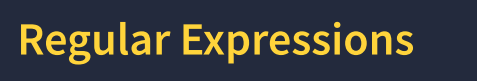

**What is a raw string?**

A **raw string** in Python treats backslashes (\) as **literal characters**, rather than interpreting them as escape sequences.

In [ ]:
# In a regular string, backslashes (\) are used to create escape sequences.
print("Hello\nWorld")

# \n is interpreted as a newline character, so "World" appears on the next line.

Hello
World


In [1]:
# A raw string (with r'') prevents escape sequences from being interpreted.
print(r"Hello\nWorld")


# The r'' tells Python to treat \n as two separate characters (\ and n) rather than a newline.

Hello\nWorld


**You can read in detail about regular expression here:**

 https://docs.python.org/3/howto/regex.html




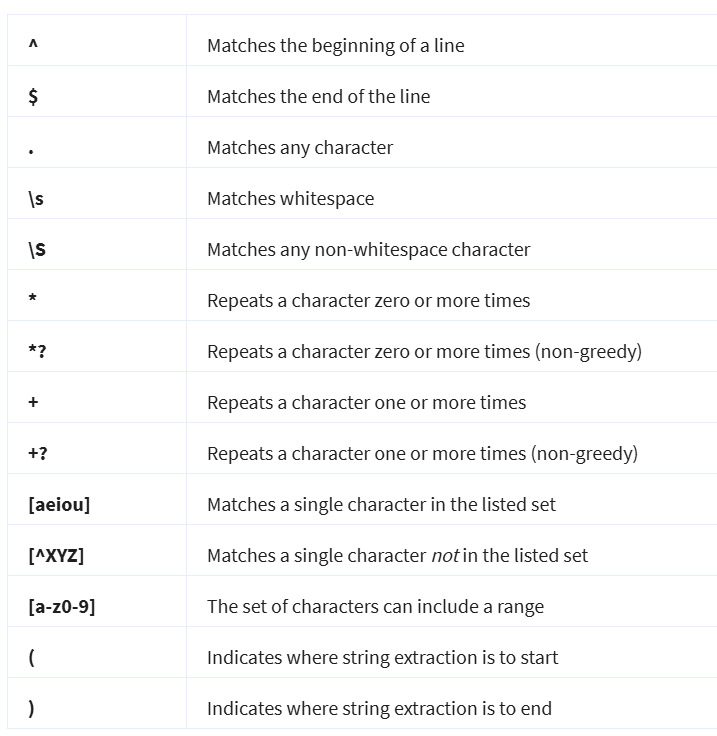

In [23]:
import re

**Simple Example** **of Regular Expression**

**Special Characters**

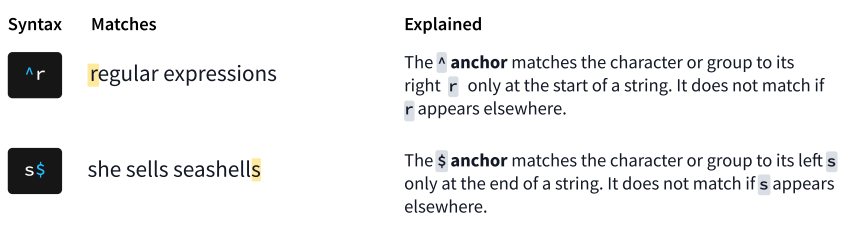

In [24]:
# Anchors: ^ (Start), $ (End)
text_anchor = "Python is fun"
if re.search(r"^Python", text_anchor):
    print(f"Anchor ^: '{text_anchor}' starts with Python")
if re.search(r"fun$", text_anchor):
    print(f"Anchor $: '{text_anchor}' ends with fun")

Anchor ^: 'Python is fun' starts with Python
Anchor $: 'Python is fun' ends with fun


**Special Characters**

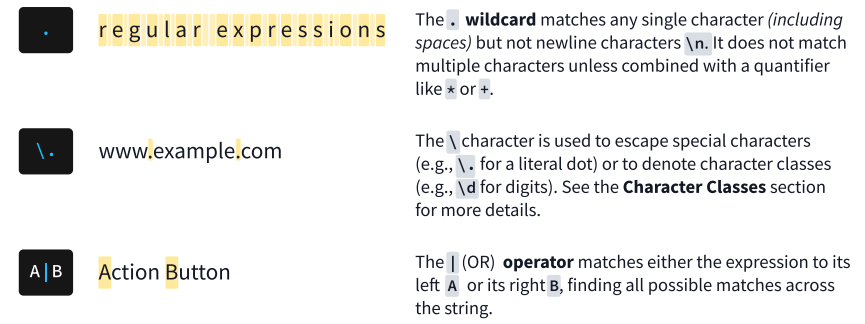

In [25]:
# Wildcards & Special: . (Any char), \ (Escape), | (OR)
# Dot matches 'a', 'e', 'i' in the middle
print(re.findall(r"b.t", "bat bet bit but")) 

# Backslash allows us to find the actual dot in a website name
print(re.search(r"google\.com", "www.google.com").group()) 

# Pipe matches "cat" OR "dog"
print(re.search(r"cat|dog", "I have a dog").group()) 

['bat', 'bet', 'bit', 'but']
google.com
dog


**Special Characters**

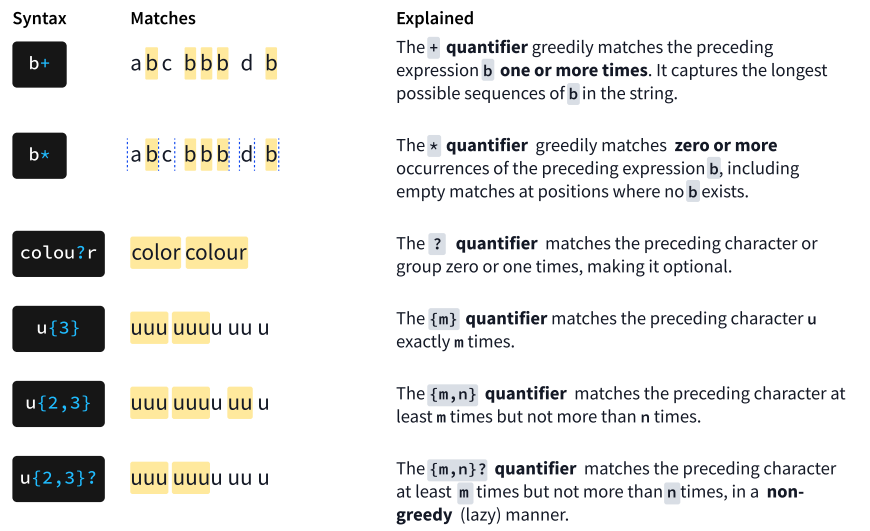

In [26]:
# + matches one or more 'o's
print(re.search(r"go+d", "goood").group()) 

# * matches zero 'o's (gd) or many 'o's (good)
print(re.search(r"go*d", "gd").group()) 

# ? makes the 'u' optional (matches color or colour)
print(re.search(r"colou?r", "color").group()) 

goood
gd
color


In [27]:
text = "The dates are 2023, 99, and 1."

# Match exactly 4 digits (like a year)
print(re.findall(r"\d{4}", text)) 

# Match numbers with 2 to 4 digits
print(re.findall(r"\d{2,4}", text)) 

['2023']
['2023', '99']


In [28]:
text = "The <bold>text</bold> is here."

# Greedy: Matches from first < to last >
print(re.search(r"<.+>", text).group()) 

# Lazy: Matches the shortest possible string starting with < and ending with >
print(re.search(r"<.+?>", text).group()) 

<bold>text</bold>
<bold>


**Sets**

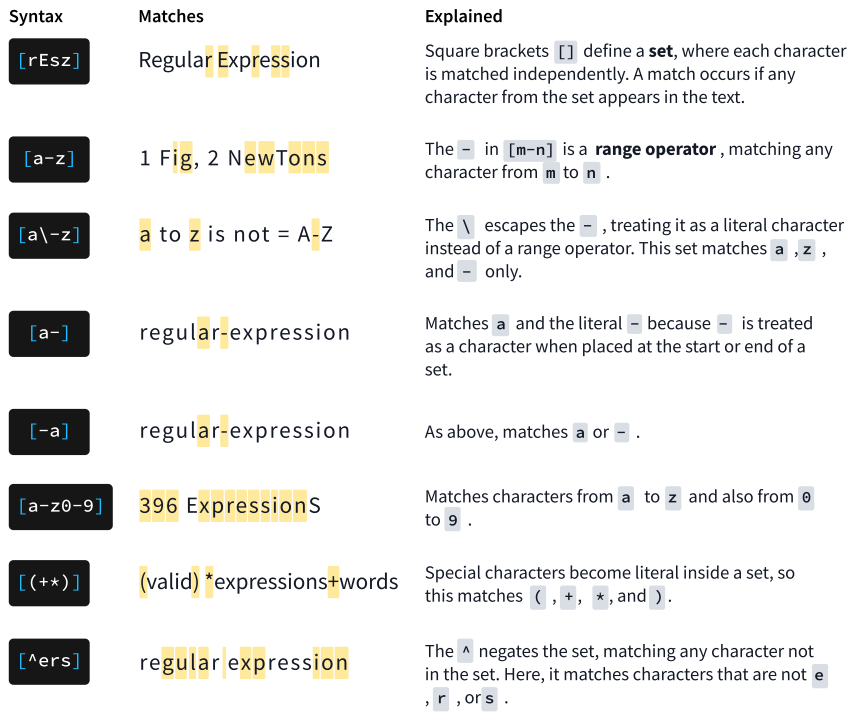

In [29]:
text = "Regular Expressions 123"

# Match specific characters (r, E, s, or z)
print(re.findall(r"[rEsz]", text))

# Match any lowercase letter
print(re.findall(r"[a-z]", text))

# Negation: Match anything NOT a lowercase letter
print(re.findall(r"[^a-z]", text))

['r', 'E', 'r', 's', 's', 's']
['e', 'g', 'u', 'l', 'a', 'r', 'x', 'p', 'r', 'e', 's', 's', 'i', 'o', 'n', 's']
['R', ' ', 'E', ' ', '1', '2', '3']


**Character Classes**

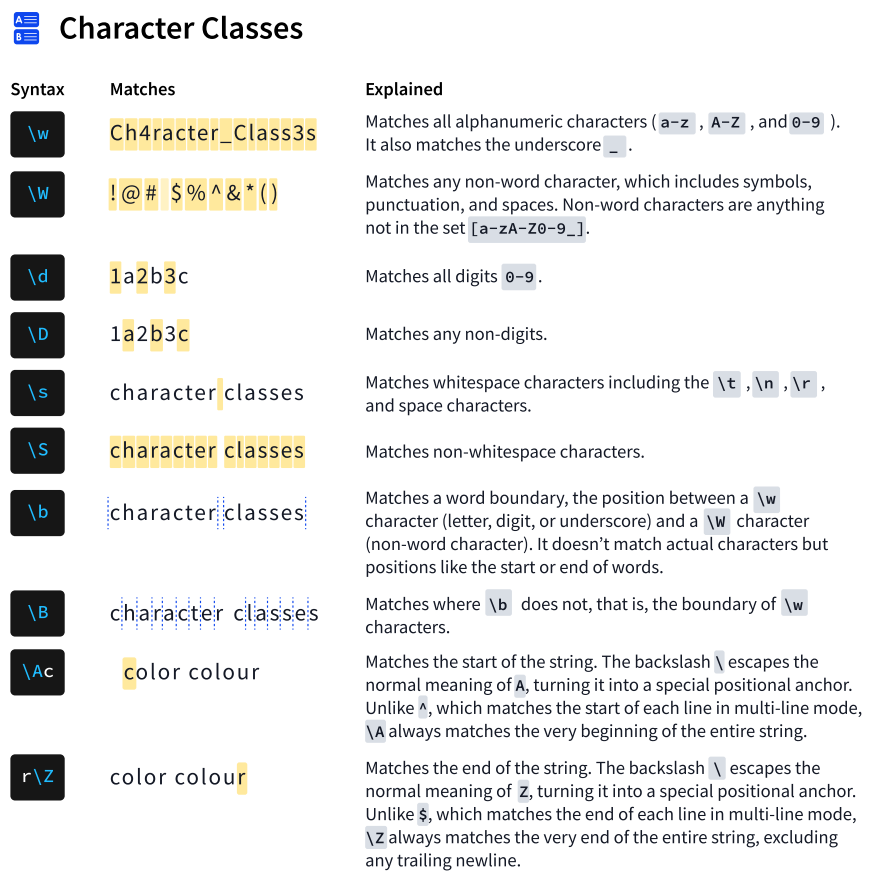

In [30]:
text = "Year: 2023!"

# \w matches Y, e, a, r, 2, 0, 2, 3
print(re.findall(r"\w", text))

# \W matches : , space, !
print(re.findall(r"\W", text))

# \d matches 2, 0, 2, 3
print(re.findall(r"\d", text))

['Y', 'e', 'a', 'r', '2', '0', '2', '3']
[':', ' ', '!']
['2', '0', '2', '3']


In [31]:
pattern = r"\d"  
print(re.findall(pattern, "There are 100 cats. 20 dogs"))

['1', '0', '0', '2', '0']


In [32]:
pattern = r"\d+"  
print(re.findall(pattern, "There are 100 cats. 20 dogs"))

['100', '20']


**Use case #1**: Extract email addresses from a given text

In [35]:
text = "Contact us at support@example.com or info@domain.org for more information. Or contact arvind.keprate@oslomet.no or arvind_ke@gmail.com or ak-kk@outlokk.com"

# Regex pattern for email extraction
email_pattern = r'[\w\.-]+@[\w\.-]+\.\w+'

emails = re.findall(email_pattern, text)
print("Extracted Emails:", emails)


Extracted Emails: ['support@example.com', 'info@domain.org', 'arvind.keprate@oslomet.no', 'arvind_ke@gmail.com', 'ak-kk@outlokk.com']


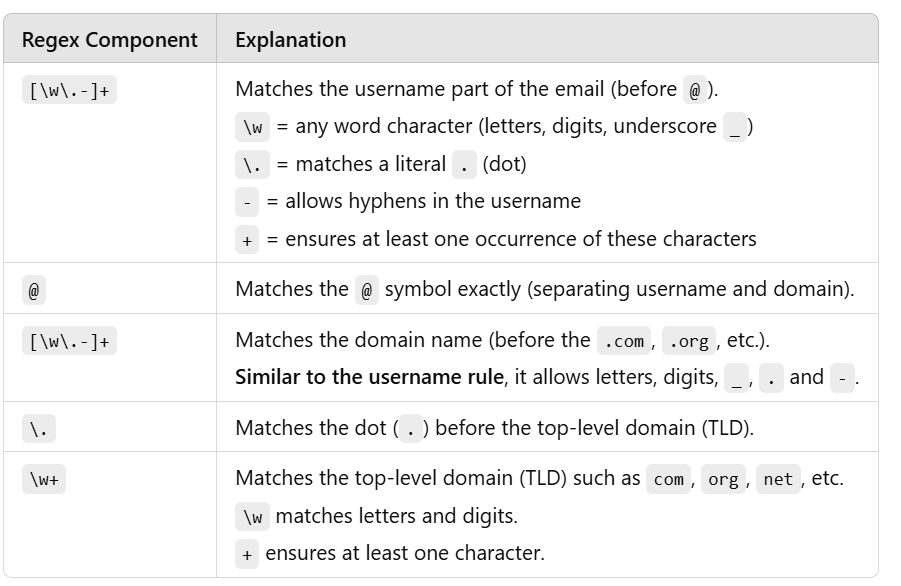

**Use case #2:** Extract phone numbers from a text with different formats.

In [36]:
text = "Call me at +1-800-555-1234 or 91-(960)-585-1236 or (123) 456-7890 or 004740386776"

# Regex pattern for phone numbers
phone_pattern = r'\+?\d{1,3}[-.\s]?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}'



phone_numbers = re.findall(phone_pattern, text)
print("Extracted Phone Numbers:", phone_numbers)



Extracted Phone Numbers: ['+1-800-555-1234', '91-(960)-585-1236', '004740386776']


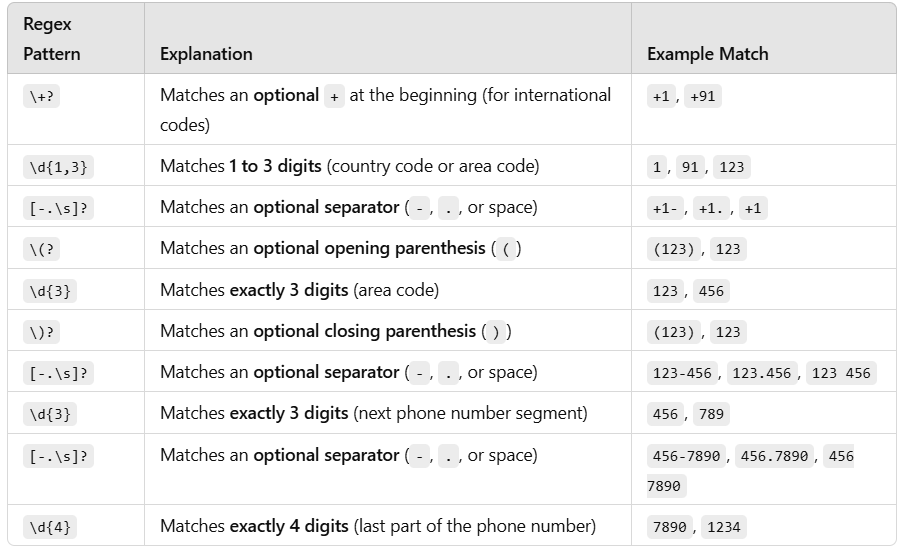

**Use case 3**: Extract website URLs from text.

In [37]:
text = "Visit https://www.google.com or http://example.org for more details."

# Regex pattern for URLs
url_pattern = r'https?://[^\s]+'

urls = re.findall(url_pattern, text)
print("Extracted URLs:", urls)


Extracted URLs: ['https://www.google.com', 'http://example.org']


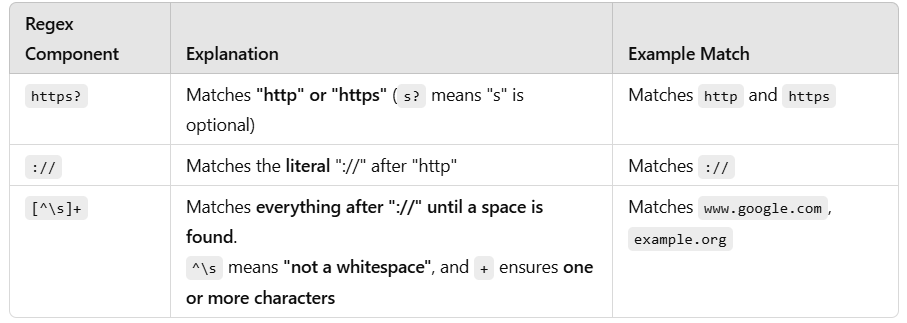

**Use case 4**: Extract all words ending in "ing" (useful in NLP).

In [38]:
text = "I am learning Python by practicing and coding regularly.hinging"

# Regex pattern for words ending in 'ing'
ing_pattern = r'\b\w+ing\b'

ing_words = re.findall(ing_pattern, text)
print("Extracted 'ing' Words:", ing_words)


Extracted 'ing' Words: ['learning', 'practicing', 'coding', 'hinging']


In [40]:
text = "The cat scattered food on the catering table."

# WITHOUT \b: Matches 'cat' everywhere
print(re.findall(r"cat", text))
# Output: ['cat', 'cat', 'cat'] (Matches: cat, s-cat-tered, cat-ering)

# WITH \b: Matches 'cat' only as a whole word
# It says: "Ensure there is a boundary (space/punctuation) on both sides of 'cat'"
print(re.findall(r"\bcat\b", text))
# Output: ['cat']

['cat', 'cat', 'cat']
['cat']


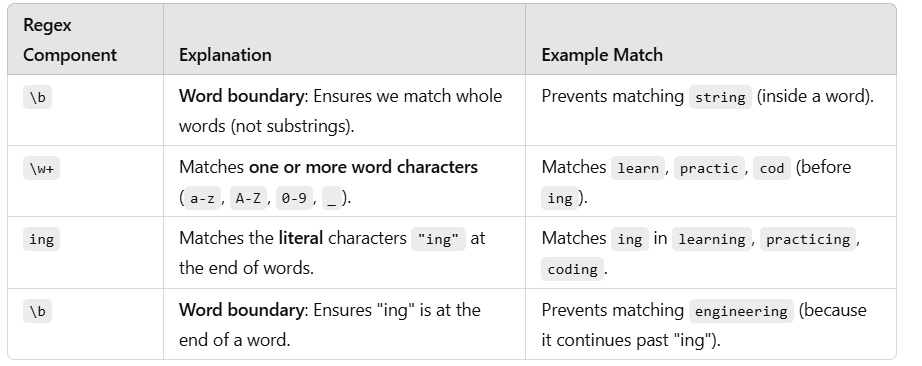

**Use case 5**: Extract full sentences that contain a specific word (e.g., "Python").

In [44]:
text = "I love Python programming. JavaScript is also great. Python is fun!"

# Regex pattern to extract sentences with 'Python'
python_sentences = re.findall(r'[^.]*Python[^.]*\.', text)

print("Sentences Containing 'Python':", python_sentences)


Sentences Containing 'Python': ['I love Python programming.']


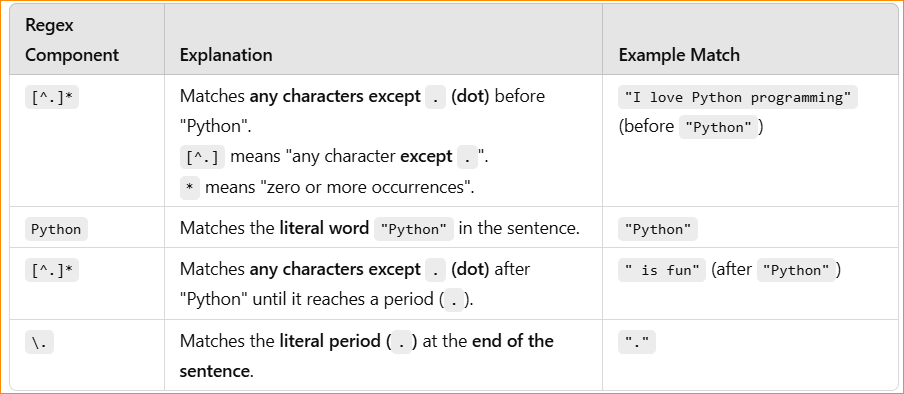

**Use case 6**: Replace curse words or sensitive words in text with asterisks.

In [ ]:
text = "This is a damn bad day!"

# List of sensitive words to censor
censored_words = ["damn", "bad"]

# Replace sensitive words with asterisks
for word in censored_words:
    text = re.sub(r'\b' + word + r'\b', '*' * len(word), text, flags=re.IGNORECASE)

print("Censored Text:", text)


Censored Text: This is a **** **** *** day!


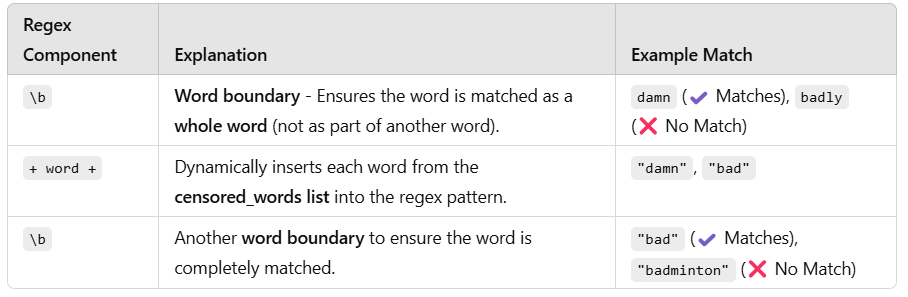

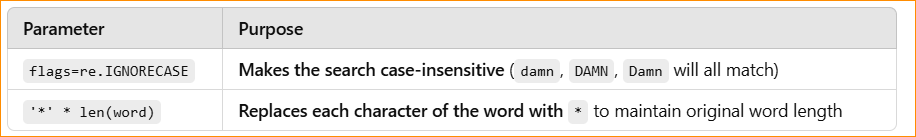

**Exercise**

In [47]:
text = """
User: john.doe@example.com connected at 2024-01-15.
His phone number is 555-0199.
Another user, jane_smith12@work.org, joined on 2024-02-20.
Contact: +1-800-555-0100.
This is a bloody mess of data!
Please fixing this immediately.
"""

Q1. Extract Email Addresses Write a regex pattern to find and print all email addresses in the text. (Hint: Remember \w matches letters/numbers and you need to match the @ symbol literal.)

Q2. Extract Dates Write a regex pattern to find all dates formatted as YYYY-MM-DD. (Hint: Use \d and quantifiers like {4}.)

Q3. Find "ing" Words Find all words that end with "ing". (Hint: Use \b to make sure you capture the whole word, similar to the "learning" example.)

Q4. Censor the "Bad" Word The word "bloody" is considered inappropriate in this context. Replace it with ******. (Hint: Use re.sub().)

Q5. Phone Number Extraction Extract the phone numbers. Note that one starts with a country code (+1-) and one does not. Try to write one pattern that catches both. (Hint: Use ? to make parts optional.)